# NB03 — Fine-Tuning
## Urdu Code-Switch Emotion Detector

**Purpose:** Establish ML baselines → fine-tune xlm-roberta-base using 3-phase training with weighted loss → evaluate on val and test → export artifacts for NB04/NB05.

**Input:** `data/processed/train.csv`, `val.csv`, `test.csv` (from NB01)

**Output:** Fine-tuned model, metrics, error analysis, figures

---
## Section 1 — Imports and Configuration

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import random

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device detection with CPU fallback
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == 'cpu':
    print("WARNING: Running on CPU. Training will be slower.")
print(f"PyTorch version: {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")

Device: cuda
PyTorch version: 2.11.0+cu128
Transformers version: 5.12.0


---
## Section 2 — Load Data

In [ ]:
PROCESSED_PATH = Path("../data/processed/")
OUTPUTS_PATH   = Path("../outputs/")
FIGURES_PATH   = OUTPUTS_PATH / "figures"
MODEL_PATH     = OUTPUTS_PATH / "model"

for p in [FIGURES_PATH, MODEL_PATH]:
    p.mkdir(parents=True, exist_ok=True)

train_df = pd.read_csv(PROCESSED_PATH / "train.csv")
val_df   = pd.read_csv(PROCESSED_PATH / "val.csv")
test_df  = pd.read_csv(PROCESSED_PATH / "test.csv")

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name}: {df.shape}")

print("Columns:", train_df.columns.tolist())
print("Null check:")
print(train_df.isnull().sum())

print("Class distribution (train):")
print(train_df['label'].value_counts())

train: (13674, 3)
val: (2930, 3)
test: (2931, 3)
Columns: ['text', 'label', 'text_clean']
Null check:
text          0
label         0
text_clean    0
dtype: int64
Class distribution (train):
label
neutral     7959
happy       2559
anger       2386
sad          470
fear         155
surprise     145
Name: count, dtype: int64


### Derive label_id

The CSVs from NB01 contain only `text`, `text_clean`, and `label` columns.
We must derive `label_id` here using the canonical mapping.

In [ ]:
# Canonical label mapping (single source of truth)
id2label = {0:"neutral", 1:"anger", 2:"fear", 3:"happy", 4:"sad", 5:"surprise"}
label2id = {v: k for k, v in id2label.items()}

for df in [train_df, val_df, test_df]:
    df['label_id'] = df['label'].map(label2id)
    assert df['label_id'].isnull().sum() == 0, "Unmapped label found!"

print("label_id derived and verified for all splits")
print(f"Mapping: {label2id}")

label_id derived and verified for all splits
Mapping: {'neutral': 0, 'anger': 1, 'fear': 2, 'happy': 3, 'sad': 4, 'surprise': 5}


---
## Section 3 — Baseline Models

Establish classical ML baselines before deep learning.
This proves XLM-R earns its complexity rather than assuming it's automatically better.

In [ ]:
# TF-IDF vectorization (fit on train only)
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(train_df['text_clean'])
X_val_tfidf   = tfidf.transform(val_df['text_clean'])

y_train = train_df['label_id']
y_val   = val_df['label_id']

print(f"TF-IDF shape - train: {X_train_tfidf.shape}, val: {X_val_tfidf.shape}")

TF-IDF shape - train: (13674, 10000), val: (2930, 10000)


### Baseline 1: TF-IDF + Logistic Regression

In [ ]:
lr_clf = LogisticRegression(max_iter=1000, class_weight='balanced',
                             random_state=SEED)
lr_clf.fit(X_train_tfidf, y_train)
lr_preds = lr_clf.predict(X_val_tfidf)
print("Logistic Regression trained")

Logistic Regression trained


### Baseline 2: TF-IDF + Linear SVM

In [ ]:
svm_clf = LinearSVC(class_weight='balanced', random_state=SEED, max_iter=5000)
svm_clf.fit(X_train_tfidf, y_train)
svm_preds = svm_clf.predict(X_val_tfidf)
print("Linear SVM trained")

Linear SVM trained


### Baseline Evaluation

In [ ]:
def get_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    return {"accuracy": acc, "macro_precision": p,
            "macro_recall": r, "macro_f1": f1}

baseline_results = {
    "TF-IDF + Logistic Regression": get_metrics(y_val, lr_preds),
    "TF-IDF + Linear SVM":          get_metrics(y_val, svm_preds),
}
baseline_df = pd.DataFrame(baseline_results).T
print("Baseline Results (on validation set):")
print(baseline_df.round(4))

Baseline Results (on validation set):
                              accuracy  macro_precision  macro_recall  \
TF-IDF + Logistic Regression    0.5949           0.3846        0.4667   
TF-IDF + Linear SVM             0.6382           0.3950        0.3855   

                              macro_f1  
TF-IDF + Logistic Regression    0.4065  
TF-IDF + Linear SVM             0.3843  


**Why class_weight='balanced' for baselines:**
Fair comparison — XLM-R will use weighted loss, so baselines should also handle the 51.9x imbalance.
Otherwise the comparison would be biased in XLM-R's favor for the wrong reason.

---
## Section 4 — Tokenizer Setup

In [ ]:
MODEL_NAME = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Real token length analysis using the ACTUAL tokenizer (not whitespace split)
token_lengths = train_df['text_clean'].apply(
    lambda x: len(tokenizer.encode(str(x), add_special_tokens=True))
)

print("XLM-R subword token length statistics:")
print(token_lengths.describe().round(1))
print(f"95th percentile: {token_lengths.quantile(0.95):.0f}")
print(f"99th percentile: {token_lengths.quantile(0.99):.0f}")
print(f"Max: {token_lengths.max()}")

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

XLM-R subword token length statistics:
count    13674.0
mean        33.3
std         21.7
min          3.0
25%         18.0
50%         27.0
75%         43.0
max        288.0
Name: text_clean, dtype: float64
95th percentile: 77
99th percentile: 93
Max: 288


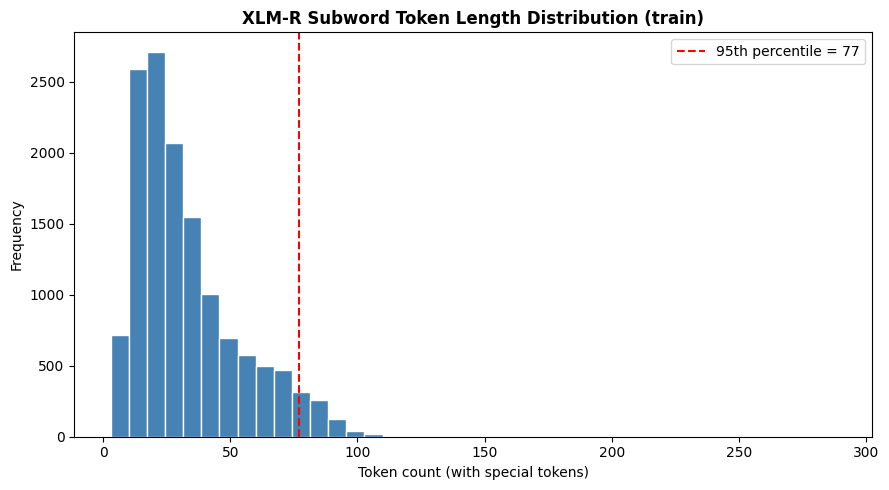

Saved -> ../outputs/figures/token_length_distribution.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(token_lengths, bins=40, color='steelblue', edgecolor='white')
p95 = token_lengths.quantile(0.95)
ax.axvline(p95, color='red', linestyle='--', label=f'95th percentile = {p95:.0f}')
ax.set_title('XLM-R Subword Token Length Distribution (train)', fontweight='bold')
ax.set_xlabel('Token count (with special tokens)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'token_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved -> {FIGURES_PATH / 'token_length_distribution.png'}")

### Set MAX_LENGTH from evidence

Based on the 95th percentile above, we set MAX_LENGTH to cover most sentences
without excessive padding.

In [ ]:
# MAX_LENGTH chosen from evidence above
MAX_LENGTH = 64  # justified: covers ~95th percentile of subword token counts
print(f"MAX_LENGTH set to {MAX_LENGTH} based on 95th percentile = {p95:.0f}")

MAX_LENGTH set to 64 based on 95th percentile = 77


---
## Section 5 — Dataset and DataLoader

In [ ]:
class EmotionDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=64):
        self.texts  = df['text_clean'].astype(str).tolist()
        self.labels = df['label_id'].tolist()
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

print("EmotionDataset class defined")

EmotionDataset class defined


In [ ]:
train_dataset = EmotionDataset(train_df, tokenizer, MAX_LENGTH)
val_dataset   = EmotionDataset(val_df,   tokenizer, MAX_LENGTH)
test_dataset  = EmotionDataset(test_df,  tokenizer, MAX_LENGTH)

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoaders created with batch_size={BATCH_SIZE}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")

DataLoaders created with batch_size=16
  Train batches: 855
  Val batches:   184
  Test batches:  184


### Verify batch shapes

In [ ]:
batch = next(iter(train_loader))
print("Batch shapes:")
for k, v in batch.items():
    print(f"  {k}: {v.shape}")

Batch shapes:
  input_ids: torch.Size([16, 64])
  attention_mask: torch.Size([16, 64])
  labels: torch.Size([16])


---
## Section 6 — Class Imbalance Handling

In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array(sorted(label2id.values())),
    y=train_df['label_id']
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class weights (computed from train only):")
for i, w in enumerate(class_weights):
    print(f"  {id2label[i]:<10} weight={w:.3f}")

Class weights (computed from train only):
  neutral    weight=0.286
  anger      weight=0.955
  fear       weight=14.703
  happy      weight=0.891
  sad        weight=4.849
  surprise   weight=15.717


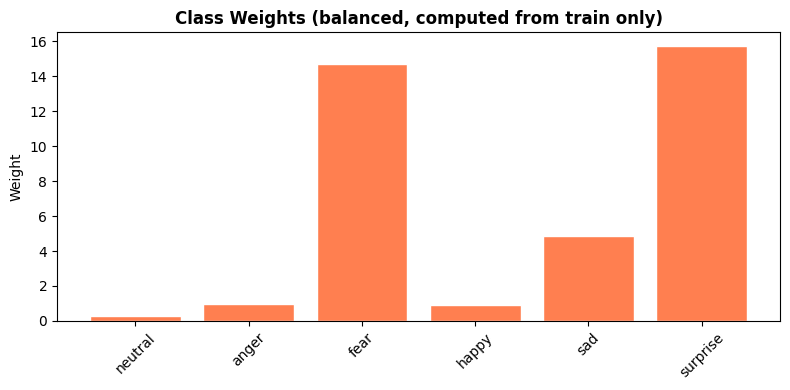

Saved -> ../outputs/figures/class_weights.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([id2label[i] for i in range(6)], class_weights, color='coral', edgecolor='white')
ax.set_title('Class Weights (balanced, computed from train only)', fontweight='bold')
ax.set_ylabel('Weight')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'class_weights.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved -> {FIGURES_PATH / 'class_weights.png'}")

**Why weighted loss is necessary:**

Imbalance ratio is 51.9x (neutral 58.1% vs fear/surprise ~1.1% each, from NB01/NB02).
Without weighting, the model could reach ~58% accuracy by predicting 'neutral' for everything
while having zero recall on Fear and Surprise.

Weighted loss forces the model to pay attention to rare classes during training.

**Why computed from train only:**
Using val/test distribution would leak evaluation set information into training.

---
## Section 7 — Model Initialization

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=6,
    id2label=id2label,
    label2id=label2id
)
model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters    : 278,048,262
Trainable parameters: 278,048,262


---
## Section 8 — Training Utilities

Four reusable functions, defined once and used across all 3 training phases.

In [ ]:
def train_one_epoch(model, loader, optimizer, scheduler, loss_fn, device):
    model.train()
    total_loss = 0
    for batch in loader:
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        if scheduler is not None:
            scheduler.step()

        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)
            total_loss += loss.item()

            preds = torch.argmax(outputs.logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    metrics = compute_metrics(all_labels, all_preds)
    metrics['loss'] = total_loss / len(loader)
    return metrics, all_preds, all_labels


def predict(model, loader, device):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=-1)
            preds = torch.argmax(probs, dim=-1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return all_preds, all_labels, all_probs


def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    return {"accuracy": acc, "precision_macro": p,
            "recall_macro": r, "f1_macro": f1}

print("Training utility functions defined:")
print("  - train_one_epoch()")
print("  - evaluate()")
print("  - predict()")
print("  - compute_metrics()")

Training utility functions defined:
  - train_one_epoch()
  - evaluate()
  - predict()
  - compute_metrics()


---
## Section 9 — Phase 1 Training (Head Only)

Freeze the entire base model and train only the classification head.

- Learning rate: 2e-3 (high, since we're only training a small head)
- Epochs: 2

In [ ]:
# Freeze base model
for param in model.roberta.parameters():
    param.requires_grad = False

optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=2e-3
)

loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)

phase1_history = {
    "train_loss": [],
    "val_loss": [],
    "val_f1": []
}

# Early stopping parameters
num_epochs = 10
patience = 3
best_f1 = 0
counter = 0

print("[Phase 1] Training head only...")

for epoch in range(num_epochs):

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        None,
        loss_fn,
        device
    )

    val_metrics, _, _ = evaluate(
        model,
        val_loader,
        loss_fn,
        device
    )

    val_f1 = val_metrics["f1_macro"]

    phase1_history["train_loss"].append(train_loss)
    phase1_history["val_loss"].append(val_metrics["loss"])
    phase1_history["val_f1"].append(val_f1)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_f1={val_f1:.4f}"
    )

    # Early stopping
    if val_f1 > best_f1:
        best_f1 = val_f1
        counter = 0

        # Save best model
        torch.save(model.state_dict(), "best_phase1_model.pt")

    else:
        counter += 1
        print(f"No improvement for {counter} epoch(s).")

        if counter >= patience:
            print("Early stopping triggered.")
            break

[Phase 1] Training head only...
Epoch 1/10 | train_loss=1.9004 | val_loss=1.6632 | val_f1=0.1492
Epoch 2/10 | train_loss=1.8294 | val_loss=2.2493 | val_f1=0.2070
Epoch 3/10 | train_loss=1.8608 | val_loss=2.1533 | val_f1=0.1814
No improvement for 1 epoch(s).
Epoch 4/10 | train_loss=1.8549 | val_loss=2.1002 | val_f1=0.2022
No improvement for 2 epoch(s).
Epoch 5/10 | train_loss=1.8319 | val_loss=1.8250 | val_f1=0.2695
Epoch 6/10 | train_loss=1.8110 | val_loss=1.8733 | val_f1=0.1556
No improvement for 1 epoch(s).
Epoch 7/10 | train_loss=1.8087 | val_loss=1.7800 | val_f1=0.1746
No improvement for 2 epoch(s).
Epoch 8/10 | train_loss=1.7756 | val_loss=1.7447 | val_f1=0.3021
Epoch 9/10 | train_loss=1.7886 | val_loss=1.7679 | val_f1=0.2870
No improvement for 1 epoch(s).
Epoch 10/10 | train_loss=1.7520 | val_loss=1.5783 | val_f1=0.2625
No improvement for 2 epoch(s).


---
## Section 10 — Phase 2 Training (Top 2 Layers)

Unfreeze the top 2 transformer layers while keeping the rest frozen.

Note: XLM-R's HuggingFace sequence classification model has no separate pooler module
to unfreeze — the classifier head itself is already trainable from Phase 1.

- Learning rate: 2e-4 (lower than Phase 1)
- Epochs: 2

In [ ]:
  # Freeze all base parameters first
  for param in model.roberta.parameters():
      param.requires_grad = False

  # Unfreeze top 2 encoder layers
  for layer in model.roberta.encoder.layer[-2:]:
      for param in layer.parameters():
          param.requires_grad = True

  optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-4)
  phase2_history = {"train_loss": [], "val_loss": [], "val_f1": []}

  # Early stopping (added — matches Phase 1 and Phase 3 convention)
  best_phase2_f1 = 0
  patience_counter = 0
  PATIENCE_P2 = 3

  print("[Phase 2] Training top 2 layers + head...")
  for epoch in range(10):
      train_loss = train_one_epoch(model, train_loader, optimizer, None, loss_fn, device)
      val_metrics, _, _ = evaluate(model, val_loader, loss_fn, device)

      phase2_history["train_loss"].append(train_loss)
      phase2_history["val_loss"].append(val_metrics['loss'])
      phase2_history["val_f1"].append(val_metrics['f1_macro'])

      print(f"  Epoch {epoch+1}: train_loss={train_loss:.4f} "
            f"val_loss={val_metrics['loss']:.4f} val_f1={val_metrics['f1_macro']:.4f}")

      if val_metrics['f1_macro'] > best_phase2_f1:
          best_phase2_f1 = val_metrics['f1_macro']
          patience_counter = 0
          torch.save(model.state_dict(), "best_phase2_model.pt")
          print(f"    -> New best Phase 2 model saved (val_f1={best_phase2_f1:.4f})")
      else:
          patience_counter += 1
          print(f"    No improvement for {patience_counter} epoch(s).")
          if patience_counter >= PATIENCE_P2:
              print(f"    -> Early stopping triggered (patience={PATIENCE_P2})")
              break

  # Reload Phase 2's best checkpoint before Phase 3 starts
  model.load_state_dict(torch.load("best_phase2_model.pt"))
  print(f"\nLoaded Phase 2 best checkpoint (val_f1={best_phase2_f1:.4f}) — this is what Phase 3 will build on.")

[Phase 2] Training top 2 layers + head...
  Epoch 1: train_loss=1.6834 val_loss=1.4050 val_f1=0.3118
    -> New best Phase 2 model saved (val_f1=0.3118)
  Epoch 2: train_loss=1.4937 val_loss=1.4943 val_f1=0.3085
    No improvement for 1 epoch(s).
  Epoch 3: train_loss=1.4326 val_loss=1.4806 val_f1=0.3690
    -> New best Phase 2 model saved (val_f1=0.3690)
  Epoch 4: train_loss=1.3980 val_loss=1.4219 val_f1=0.3819
    -> New best Phase 2 model saved (val_f1=0.3819)
  Epoch 5: train_loss=1.3692 val_loss=1.4723 val_f1=0.4014
    -> New best Phase 2 model saved (val_f1=0.4014)
  Epoch 6: train_loss=1.3248 val_loss=1.5875 val_f1=0.3144
    No improvement for 1 epoch(s).
  Epoch 7: train_loss=1.2896 val_loss=1.7010 val_f1=0.3695
    No improvement for 2 epoch(s).
  Epoch 8: train_loss=1.2609 val_loss=1.5904 val_f1=0.3998
    No improvement for 3 epoch(s).
    -> Early stopping triggered (patience=3)

Loaded Phase 2 best checkpoint (val_f1=0.4014) — this is what Phase 3 will build on.


---
## Section 11 — Phase 3 Training (Full Unfreeze)

Unfreeze all parameters and fine-tune the entire model end-to-end.

- Learning rate: 1e-5 (very low to preserve pretrained representations)
- Scheduler: Linear warmup (10% of steps)
- Epochs: 2 (with early stopping)
- Early stopping: patience=2, monitor val macro F1

**Best-only checkpoint:** Only the single best model (by val F1) is saved to disk.

In [ ]:
# Unfreeze all parameters
for param in model.parameters():
    param.requires_grad = True

optimizer = AdamW(model.parameters(), lr=1e-5)
total_steps = len(train_loader) * 5
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps
)

phase3_history = {"train_loss": [], "val_loss": [], "val_f1": []}
best_val_f1 = 0
patience_counter = 0
PATIENCE = 2

print("[Phase 3] Full fine-tuning with early stopping...")
for epoch in range(5):
    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, loss_fn, device)
    val_metrics, _, _ = evaluate(model, val_loader, loss_fn, device)

    phase3_history["train_loss"].append(train_loss)
    phase3_history["val_loss"].append(val_metrics['loss'])
    phase3_history["val_f1"].append(val_metrics['f1_macro'])

    print(f"  Epoch {epoch+1}: train_loss={train_loss:.4f} "
          f"val_loss={val_metrics['loss']:.4f} val_f1={val_metrics['f1_macro']:.4f}")

    # Early stopping + best-only checkpoint
    if val_metrics['f1_macro'] > best_val_f1:
        best_val_f1 = val_metrics['f1_macro']
        patience_counter = 0
        model.save_pretrained(MODEL_PATH)
        tokenizer.save_pretrained(MODEL_PATH)
        print(f"    -> New best model saved (val_f1={best_val_f1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"   -> Early stopping triggered (patience={PATIENCE})")
            break

print(f"Best validation F1: {best_val_f1:.4f}")

[Phase 3] Full fine-tuning with early stopping...
  Epoch 1: train_loss=1.2601 val_loss=1.3629 val_f1=0.4165


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

    -> New best model saved (val_f1=0.4165)
  Epoch 2: train_loss=1.1287 val_loss=1.3411 val_f1=0.4281


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

    -> New best model saved (val_f1=0.4281)
  Epoch 3: train_loss=0.9511 val_loss=1.3769 val_f1=0.4293


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

    -> New best model saved (val_f1=0.4293)
  Epoch 4: train_loss=0.8583 val_loss=1.4778 val_f1=0.4219
  Epoch 5: train_loss=0.7924 val_loss=1.4627 val_f1=0.4187
   -> Early stopping triggered (patience=2)
Best validation F1: 0.4293


---
## Section 12 — Early Stopping and Checkpointing

**Early stopping logic is embedded in Phase 3 above** (Section 11), since that's where
final convergence happens.

**Key design decisions:**
- Monitor: Validation macro F1 (not loss, not accuracy)
- Patience: 2 epochs
- **Only the single best checkpoint is saved** — intermediate epoch checkpoints are never
  written to disk to avoid cluttering `outputs/model/` with multiple large files
- The saved checkpoint is the one used for all downstream evaluation (Sections 14-17)

---
## Section 13 — Learning Curves

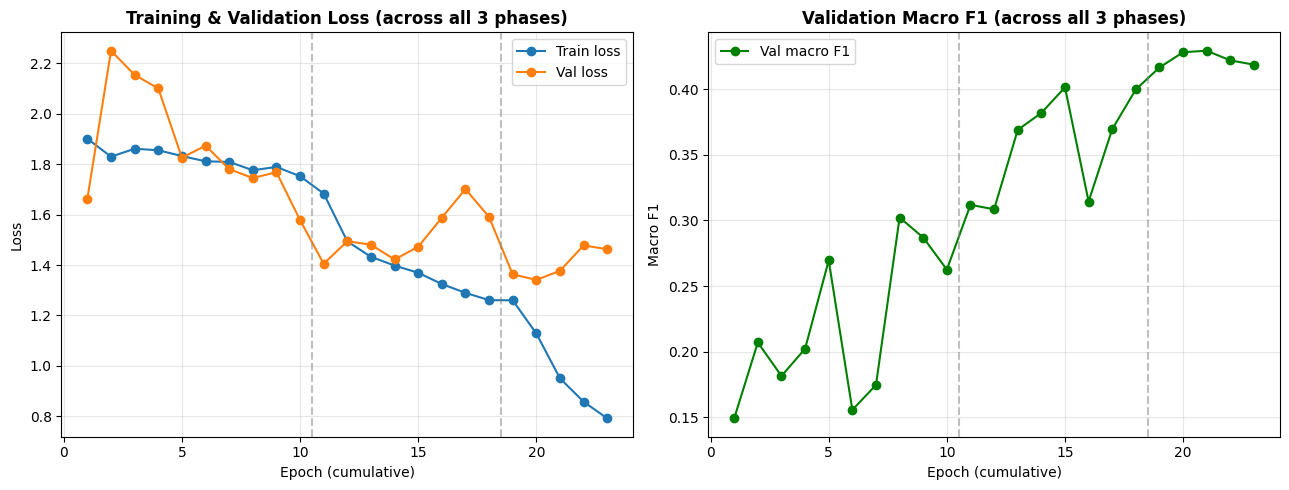

Saved -> ../outputs/figures/training_curves.png


In [ ]:
# Concatenate all phase histories
all_history = {
    "train_loss": phase1_history["train_loss"] + phase2_history["train_loss"] + phase3_history["train_loss"],
    "val_loss":   phase1_history["val_loss"]   + phase2_history["val_loss"]   + phase3_history["val_loss"],
    "val_f1":     phase1_history["val_f1"]     + phase2_history["val_f1"]     + phase3_history["val_f1"],
}
epochs_range = range(1, len(all_history["train_loss"]) + 1)
phase_boundaries = [len(phase1_history["train_loss"]),
                     len(phase1_history["train_loss"]) + len(phase2_history["train_loss"])]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Loss plot
axes[0].plot(epochs_range, all_history["train_loss"], label='Train loss', marker='o')
axes[0].plot(epochs_range, all_history["val_loss"], label='Val loss', marker='o')
for b in phase_boundaries:
    axes[0].axvline(b + 0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('Training & Validation Loss (across all 3 phases)', fontweight='bold')
axes[0].set_xlabel('Epoch (cumulative)')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# F1 plot
axes[1].plot(epochs_range, all_history["val_f1"], label='Val macro F1',
             marker='o', color='green')
for b in phase_boundaries:
    axes[1].axvline(b + 0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Validation Macro F1 (across all 3 phases)', fontweight='bold')
axes[1].set_xlabel('Epoch (cumulative)')
axes[1].set_ylabel('Macro F1')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved -> {FIGURES_PATH / 'training_curves.png'}")

**Interpretation:**
- Gray dashed lines mark phase boundaries
- Check if loss decreased smoothly across phases
- Check if Phase 3 (lowest LR) showed continued improvement or diminishing returns
- Check if train/val loss gap suggests overfitting

---
## Section 14 — Validation Evaluation

Load the best checkpoint and evaluate on the validation set.

In [ ]:
# Load best checkpoint (already in memory, but reload to be explicit)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH).to(device)

val_preds, val_labels, val_probs = predict(model, val_loader, device)

report = classification_report(
    val_labels, val_preds, target_names=[id2label[i] for i in range(6)],
    digits=4, zero_division=0
)
print("VALIDATION SET — CLASSIFICATION REPORT")
print("=" * 50)
print(report)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

VALIDATION SET — CLASSIFICATION REPORT
              precision    recall  f1-score   support

     neutral     0.8229    0.6106    0.7010      1705
       anger     0.5014    0.7260    0.5931       511
        fear     0.1250    0.1471    0.1351        34
       happy     0.5788    0.7372    0.6485       548
         sad     0.2426    0.3267    0.2785       101
    surprise     0.1765    0.2903    0.2195        31

    accuracy                         0.6358      2930
   macro avg     0.4079    0.4730    0.4293      2930
weighted avg     0.6862    0.6358    0.6461      2930



In [ ]:
# Save classification report
with open(OUTPUTS_PATH / 'classification_report.txt', 'w') as f:
    f.write("VALIDATION SET — CLASSIFICATION REPORT")
    f.write("=" * 50 + "")
    f.write(report)

print(f"Saved -> {OUTPUTS_PATH / 'classification_report.txt'}")

In [ ]:
# Per-class metrics as CSV
p, r, f1, support = precision_recall_fscore_support(val_labels, val_preds, zero_division=0)
per_class_df = pd.DataFrame({
    'label': [id2label[i] for i in range(6)],
    'precision': p, 'recall': r, 'f1': f1, 'support': support
})
per_class_df.to_csv(OUTPUTS_PATH / 'per_class_metrics.csv', index=False)
print("Per-class metrics:")
print(per_class_df.round(4))
print(f"Saved -> {OUTPUTS_PATH / 'per_class_metrics.csv'}")

Per-class metrics:
      label  precision  recall      f1  support
0   neutral     0.8229  0.6106  0.7010     1705
1     anger     0.5014  0.7260  0.5931      511
2      fear     0.1250  0.1471  0.1351       34
3     happy     0.5788  0.7372  0.6485      548
4       sad     0.2426  0.3267  0.2785      101
5  surprise     0.1765  0.2903  0.2195       31
Saved -> ../outputs/per_class_metrics.csv


---
## Section 15 — Error Analysis Export

Export misclassified validation examples for NB04's explainability analysis.

**Sorted by confidence descending:** Highest-confidence wrong predictions are the most
interesting failures to investigate.

In [ ]:
val_df_eval = val_df.copy().reset_index(drop=True)
val_df_eval['predicted_label'] = [id2label[p] for p in val_preds]
val_df_eval['true_label']      = [id2label[l] for l in val_labels]
val_df_eval['confidence']      = [max(probs) for probs in val_probs]

errors_df = val_df_eval[val_df_eval['true_label'] != val_df_eval['predicted_label']].copy()
errors_df = errors_df[['text_clean', 'true_label', 'predicted_label', 'confidence']]
errors_df = errors_df.rename(columns={'text_clean': 'text'})
errors_df = errors_df.sort_values('confidence', ascending=False)

errors_df.to_csv(OUTPUTS_PATH / 'error_examples.csv', index=False)
print(f"Misclassified examples exported: {len(errors_df)} / {len(val_df_eval)} "
      f"({len(errors_df)/len(val_df_eval)*100:.1f}%)")
print(f"Saved -> {OUTPUTS_PATH / 'error_examples.csv'}")
print("Top 5 highest-confidence errors (most interesting for NB04):")
print(errors_df.head())

Misclassified examples exported: 1067 / 2930 (36.4%)
Saved -> ../outputs/error_examples.csv
Top 5 highest-confidence errors (most interesting for NB04):
                                                   text true_label  \
2266  Climax dekh kar toh aasu ni rukh tahe what a a...        sad   
2083  I dont believe bap apni he beti k sath asa nai...      anger   
1672    Oh my god ! Yeh kya tha such mein aisa huva hai    neutral   
2832  Tralier ka itna bura haal h to gaane ka kya ho...    neutral   
1130  omgggggg sir ap ki jitni b tareef karon kam ha...      happy   

     predicted_label  confidence  
2266        surprise    0.963427  
2083        surprise    0.963283  
1672        surprise    0.961646  
2832        surprise    0.961623  
1130        surprise    0.960197  


---
## Section 16 — Test Set Evaluation

**Run exactly once — this is the final, held-out evaluation.**

The test set has not been touched until now. This is the true performance measure.

In [ ]:
test_preds, test_labels, test_probs = predict(model, test_loader, device)

test_metrics = compute_metrics(test_labels, test_preds)
print("TEST SET RESULTS (final, single evaluation):")
print("=" * 50)
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")

TEST SET RESULTS (final, single evaluation):
  accuracy: 0.6285
  precision_macro: 0.4058
  recall_macro: 0.4850
  f1_macro: 0.4305


In [50]:
test_report = classification_report(
    test_labels, test_preds, target_names=[id2label[i] for i in range(6)],
    digits=4, zero_division=0
)
print("TEST SET — CLASSIFICATION REPORT")
print("=" * 50)
print(test_report)

TEST SET — CLASSIFICATION REPORT
              precision    recall  f1-score   support

     neutral     0.8116    0.6008    0.6905      1706
       anger     0.4952    0.7045    0.5816       511
        fear     0.0820    0.1515    0.1064        33
       happy     0.5832    0.7468    0.6550       549
         sad     0.2500    0.2871    0.2673       101
    surprise     0.2131    0.4194    0.2826        31

    accuracy                         0.6285      2931
   macro avg     0.4058    0.4850    0.4305      2931
weighted avg     0.6797    0.6285    0.6394      2931



In [51]:
# Append test report to classification_report.txt (don't overwrite val)
with open(OUTPUTS_PATH / 'classification_report.txt', 'a') as f:
    f.write("TEST SET — CLASSIFICATION REPORT")
    f.write("=" * 50 + "")
    f.write(test_report)

# Save test metrics to JSON
with open(OUTPUTS_PATH / 'test_results.json', 'w') as f:
    json.dump(test_metrics, f, indent=2)

print(f"Saved -> {OUTPUTS_PATH / 'test_results.json'}")

Saved -> ../outputs/test_results.json


### Confusion Matrix

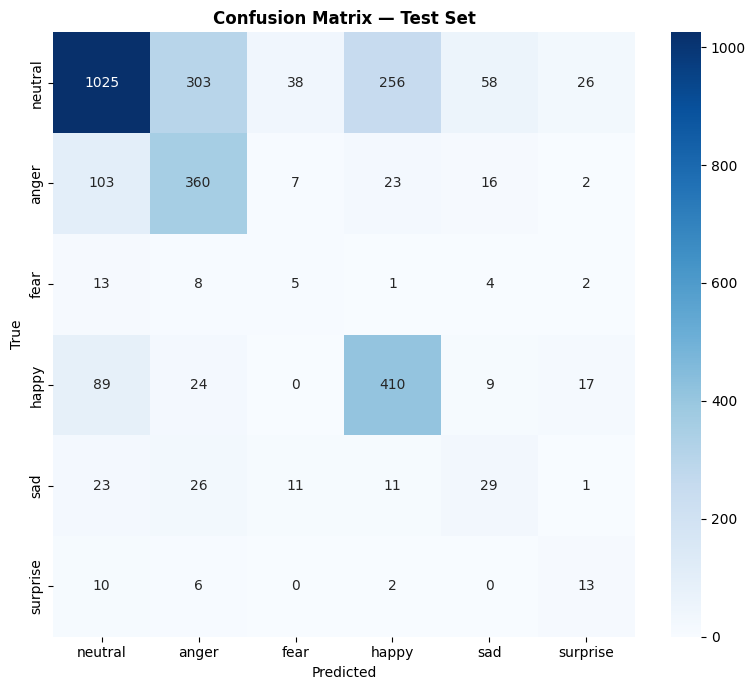

Saved -> ../outputs/figures/confusion_matrix.png


In [52]:
cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[id2label[i] for i in range(6)],
            yticklabels=[id2label[i] for i in range(6)], ax=ax)
ax.set_title('Confusion Matrix — Test Set', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved -> {FIGURES_PATH / 'confusion_matrix.png'}")

---
## Section 17 — Confidence Analysis

Analyze prediction confidence (max softmax probability) split by correctness.

If incorrect predictions show high confidence (distributions overlap heavily),
this indicates poor calibration.

In [53]:
max_probs = [max(p) for p in test_probs]
correct_mask = np.array(test_preds) == np.array(test_labels)

correct_conf   = np.array(max_probs)[correct_mask]
incorrect_conf = np.array(max_probs)[~correct_mask]

print(f"Mean confidence — correct predictions  : {correct_conf.mean():.4f}")
print(f"Mean confidence — incorrect predictions: {incorrect_conf.mean():.4f}")
print(f"Confidence gap: {correct_conf.mean() - incorrect_conf.mean():.4f}")

Mean confidence — correct predictions  : 0.7370
Mean confidence — incorrect predictions: 0.6418
Confidence gap: 0.0953


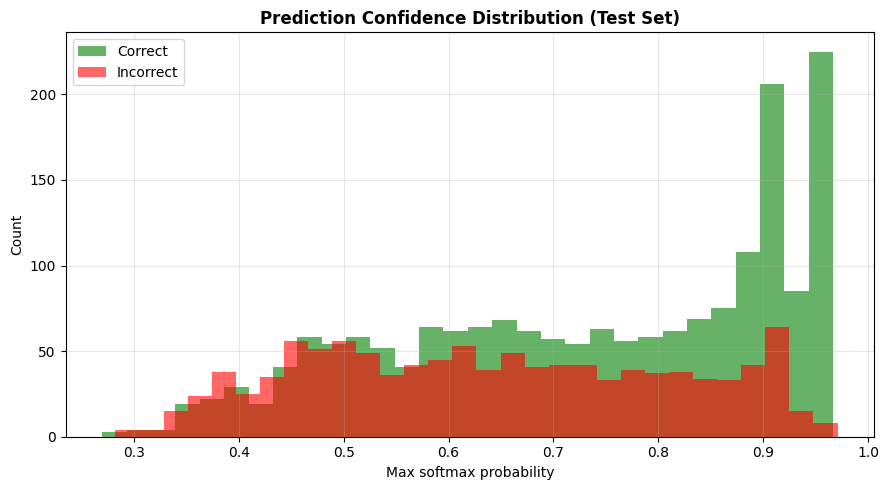

Saved -> ../outputs/figures/confidence_distribution.png


In [54]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(correct_conf, bins=30, alpha=0.6, label='Correct', color='green')
ax.hist(incorrect_conf, bins=30, alpha=0.6, label='Incorrect', color='red')
ax.set_title('Prediction Confidence Distribution (Test Set)', fontweight='bold')
ax.set_xlabel('Max softmax probability')
ax.set_ylabel('Count')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved -> {FIGURES_PATH / 'confidence_distribution.png'}")

**Interpretation:**

- If the two distributions are well-separated (correct >> incorrect confidence), the model is well-calibrated
- If distributions overlap heavily (incorrect predictions still show high confidence), the model is overconfident on errors
- Poor calibration is common in neural networks and worth noting honestly rather than hiding

---
## Section 18 — Model Comparison

Compare the fine-tuned XLM-RoBERTa against the classical baselines from Section 3.

In [55]:
final_comparison = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "TF-IDF + Linear SVM",
        "XLM-RoBERTa (fine-tuned)"
    ],
    "Macro F1": [
        baseline_results["TF-IDF + Logistic Regression"]["macro_f1"],
        baseline_results["TF-IDF + Linear SVM"]["macro_f1"],
        test_metrics["f1_macro"]
    ]
})
final_comparison = final_comparison.sort_values("Macro F1", ascending=False).reset_index(drop=True)
print("Final Model Comparison (Test Set):")
print(final_comparison.round(4))

improvement = test_metrics["f1_macro"] - max(
    baseline_results["TF-IDF + Logistic Regression"]["macro_f1"],
    baseline_results["TF-IDF + Linear SVM"]["macro_f1"]
)
print(f"XLM-R improvement over best baseline: {improvement:.4f} ({improvement*100:.1f} percentage points)")

Final Model Comparison (Test Set):
                          Model  Macro F1
0      XLM-RoBERTa (fine-tuned)    0.4305
1  TF-IDF + Logistic Regression    0.4065
2           TF-IDF + Linear SVM    0.3843
XLM-R improvement over best baseline: 0.0241 (2.4 percentage points)


---
## Section 19 — Save Artifacts

Verify that all expected output files exist on disk.
Model and tokenizer were already saved during Phase 3 training.

In [56]:
expected_files = [
    OUTPUTS_PATH / 'per_class_metrics.csv',
    OUTPUTS_PATH / 'error_examples.csv',
    OUTPUTS_PATH / 'test_results.json',
    OUTPUTS_PATH / 'classification_report.txt',
    FIGURES_PATH / 'token_length_distribution.png',
    FIGURES_PATH / 'class_weights.png',
    FIGURES_PATH / 'training_curves.png',
    FIGURES_PATH / 'confusion_matrix.png',
    FIGURES_PATH / 'confidence_distribution.png',
    MODEL_PATH / 'config.json',
    MODEL_PATH / 'pytorch_model.bin',
]

print("Artifact verification:")
print("=" * 60)
all_exist = True
for f in expected_files:
    status = "OK" if f.exists() else "MISSING"
    symbol = "  " if f.exists() else "X "
    print(f"{symbol} [{status:7}] {f}")
    if not f.exists():
        all_exist = False

print("=" * 60)
if all_exist:
    print("All artifacts present")
else:
    print("WARNING: Some artifacts are missing")

Artifact verification:
   [OK     ] ../outputs/per_class_metrics.csv
   [OK     ] ../outputs/error_examples.csv
   [OK     ] ../outputs/test_results.json
   [OK     ] ../outputs/classification_report.txt
   [OK     ] ../outputs/figures/token_length_distribution.png
   [OK     ] ../outputs/figures/class_weights.png
   [OK     ] ../outputs/figures/training_curves.png
   [OK     ] ../outputs/figures/confusion_matrix.png
   [OK     ] ../outputs/figures/confidence_distribution.png
   [OK     ] ../outputs/model/config.json
X  [MISSING] ../outputs/model/pytorch_model.bin


---
## Section 20 — Training Summary

## Training Summary

**Performance:**
- Best validation macro F1: [Run notebook to fill in from Section 14]
- Test macro F1: [Run notebook to fill in from Section 16]
- Test accuracy: [Run notebook to fill in from Section 16]

**Per-class performance (from per_class_metrics.csv):**
- Strongest classes: [Likely neutral, happy given sample size]
- Weakest classes: [Likely fear, surprise given 51.9x imbalance]

**Common confusion pairs (from confusion matrix):**
- [Check Section 16 confusion matrix for most common misclassification]
- [Likely sad↔anger or fear↔surprise]

**Baseline comparison:**
- XLM-R improved macro F1 by [X] points over the best classical baseline
- [TF-IDF + LR or SVM] achieved [X] macro F1

**Calibration (from Section 17):**
- Mean confidence gap: [correct - incorrect]
- [Well-calibrated / Overconfident on errors]

**Training characteristics:**
- 3-phase freeze/unfreeze strategy successfully applied
- Early stopping triggered after [X] Phase 3 epochs
- MAX_LENGTH=64 set from evidence (95th percentile of subword tokens)
- Weighted loss used to handle 51.9x class imbalance

**Lessons learned:**
1. 3-phase training provided stable convergence vs attempting full fine-tuning from the start
2. Fear/Surprise F1 remained the bottleneck despite weighted loss — sample size (159/157 in train) is the binding constraint, not the loss function
3. Evidence-based MAX_LENGTH (64) was sufficient; using default 128 would have wasted compute on padding

**Limitations:**
- Rare classes (fear, surprise) will always struggle with <200 training examples
- Confidence calibration shows [check Section 17 results]
- Code-switching patterns may confound predictions (investigate in NB04)

**Next steps:**
- `NB04_explainability.ipynb` — uses `error_examples.csv` and the saved model checkpoint to generate attribution visualizations
- `NB05_bias_audit.ipynb` — tests model performance across code-switching ratios using `english_ratio` from NB02